In [2]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# 1. `datetime` Module

In [5]:
from datetime import date, time, datetime, timedelta

d = date(year = 2020, month = 1, day = 31)
d = date(2020, 1, 31)
print(d.year)
print(d.month)
print(d.day)
print(type(d)) # 할당된 변수의 자료형 : datetime

2020
1
31
<class 'datetime.date'>


In [9]:
t = time(hour = 13, minute = 14, second = 31)
print(t.hour)
print(t.minute)
print(t.second)
print(t.tzinfo)

13
14
31
None


In [10]:
dt = datetime(year = 2020, month = 1, day = 31,
							hour = 13, minute = 14, second = 31)

In [11]:
# 오늘 날짜 확인
today = date.today()
today

datetime.date(2025, 2, 26)

In [12]:
# 현재 시각 확인
now = datetime.now()
now

datetime.datetime(2025, 2, 26, 7, 50, 54, 955522)

In [13]:
# 시간대 확인
tz = now.astimezone()
tz
tz.tzname()

'UTC'

In [14]:
# 시간과 날짜의 결합
current_time = time(now.hour, now.minute, now.second)
current_time
datetime.combine(today, current_time)

datetime.datetime(2025, 2, 26, 7, 50, 54)

## 문자열로부터 `datetime` 객체 생성

In [15]:
# ISO 표준형으로 표기된 경우
date.fromisoformat("2020-01-31")

datetime.date(2020, 1, 31)

In [16]:
# 표준형이 아닌 경우
date_string = "01-31-2020 14:45:37"
format_string = "%m-%d-%Y %H:%M:%S"
datetime.strptime(date_string, format_string)

datetime.datetime(2020, 1, 31, 14, 45, 37)

## 시간과 날짜의 연산

In [17]:
# countdown
dday = datetime(year = 2025, month = 8, day = 25, hour = 10)
countdown = dday - datetime.now()
print(f"Countdown to Graduation: {countdown}")

Countdown to Graduation: 180 days, 2:07:09.640018


In [18]:
# timedelta : 두 객체의 시간차이를 표현
from datetime import timedelta

delta = datetime(2011, 1, 7) - datetime(2008, 6, 24, 8, 15)
delta
delta.days
delta.seconds

56700

In [19]:
now = datetime.now()
now

d_tomorrow = timedelta(days = +1)
d_tomorrow

tomorrow = now + d_tomorrow
tomorrow

d_yesterday = timedelta(days = -1)
d_yesterday

tomorrow = now + d_tomorrow
tomorrow

delta = timedelta(days = +3, hours = -4)
now + delta

datetime.datetime(2025, 3, 1, 3, 53, 6, 490350)

In [20]:
# !pip install python-dateutil

from dateutil.relativedelta import relativedelta

d_tomorrow = relativedelta(days = +1)
now + d_tomorrow

delta = relativedelta(years = +5, months = +1, days = +3,
                      hours = -4, minutes = -30)
now + delta

datetime.datetime(2030, 3, 29, 3, 23, 6, 490350)

In [21]:
tomorrow = datetime(2020, 1, 27, 9, 37, 46, 380905)
relativedelta(now, tomorrow)

relativedelta(years=+5, days=+29, hours=+22, minutes=+15, seconds=+20, microseconds=+109445)

# 2. Pandas 에서의 시간/날짜 다루기

In [22]:
datestrs = ["2011-07-06 12:00:00", "2011-08-06 00:00:00"]
pd.to_datetime(datestrs)

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00'], dtype='datetime64[ns]', freq=None)

In [23]:
dates = [datetime(2011, 1, 2), datetime(2011, 1, 5),
         datetime(2011, 1, 7), datetime(2011, 1, 8),
         datetime(2011, 1, 10), datetime(2011, 1, 12)]
ts = pd.Series(np.random.standard_normal(6), index=dates)
ts

,0
2011-01-02,-0.903057
2011-01-05,0.928241
2011-01-07,-0.201343
2011-01-08,-0.063678
2011-01-10,-0.757428
2011-01-12,-0.042700


In [24]:
ts.index
ts.index[0]

Timestamp('2011-01-02 00:00:00')

In [25]:
# `datetime` vs. `Timestamp`
ts.index.dtype

dtype('<M8[ns]')

## 시간/날짜 색인

In [27]:
# 시간/날짜 색인
stamp = ts.index[2]
ts[stamp]

ts["2011-01-10"] # string으로도 가능

-0.7574283016470725

In [28]:
longer_ts = pd.Series(np.random.standard_normal(1000),
                      index=pd.date_range("2000-01-01", periods=1000))
longer_ts
longer_ts["2001"]    # 2001년의 데이터
longer_ts["2001-05"] # 2001녀 5월의 데이터

,0
2001-05-01,0.435153
2001-05-02,-0.285249
2001-05-03,0.000640
2001-05-04,0.596552
2001-05-05,0.508226
2001-05-06,0.091848
2001-05-07,-0.712200
2001-05-08,-1.031937
2001-05-09,-0.493905
2001-05-10,0.280466


In [29]:
ts["2011-01-06":"2011-01-11"]
ts.truncate(after = "2011-01-09")

,0
2011-01-02,-0.903057
2011-01-05,0.928241
2011-01-07,-0.201343
2011-01-08,-0.063678


In [30]:
dates = pd.date_range("2000-01-01", periods=100, freq="W-WED")
long_df = pd.DataFrame(np.random.standard_normal((100, 4)),
                       index=dates,
                       columns=["Colorado", "Texas",
                                "New York", "Ohio"])
long_df.loc["2001-05"]

,Colorado,Texas,New York,Ohio
2001-05-02,-1.188002,-0.519707,-0.240463,-0.936345
2001-05-09,-0.248512,-0.465982,-0.017259,1.681751
2001-05-16,1.680983,0.903552,0.651070,-2.067871
2001-05-23,-1.562139,0.281400,-0.621550,-0.146701
2001-05-30,-0.905040,1.531723,-0.697891,0.984709


## 날짜 범위

In [31]:
# 시작 및 종료 날짜 지정
index = pd.date_range("2012-04-01", "2012-06-01")
index

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20',
               '2012-04-21', '2012-04-22', '2012-04-23', '2012-04-24',
               '2012-04-25', '2012-04-26', '2012-04-27', '2012-04-28',
               '2012-04-29', '2012-04-30', '2012-05-01', '2012-05-02',
               '2012-05-03', '2012-05-04', '2012-05-05', '2012-05-06',
               '2012-05-07', '2012-05-08', '2012-05-09', '2012-05-10',
               '2012-05-11', '2012-05-12', '2012-05-13', '2012-05-14',
               '2012-05-15', '2012-05-16', '2012-05-17', '2012-05-18',
               '2012-05-19', '2012-05-20', '2012-05-21', '2012-05-22',
               '2012-05-23', '2012-05-24', '2012-05-25', '2012-05-26',
      

In [32]:
# 기준날짜와 기간 지정
pd.date_range(start = "2012-04-01", periods = 20)

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20'],
              dtype='datetime64[ns]', freq='D')

In [33]:
pd.date_range(end = "2012-06-01", periods = 20)

DatetimeIndex(['2012-05-13', '2012-05-14', '2012-05-15', '2012-05-16',
               '2012-05-17', '2012-05-18', '2012-05-19', '2012-05-20',
               '2012-05-21', '2012-05-22', '2012-05-23', '2012-05-24',
               '2012-05-25', '2012-05-26', '2012-05-27', '2012-05-28',
               '2012-05-29', '2012-05-30', '2012-05-31', '2012-06-01'],
              dtype='datetime64[ns]', freq='D')

In [34]:
# 빈도의 지정
pd.date_range("2000-01-01", "2000-12-01")

DatetimeIndex(['2000-01-01', '2000-01-02', '2000-01-03', '2000-01-04',
               '2000-01-05', '2000-01-06', '2000-01-07', '2000-01-08',
               '2000-01-09', '2000-01-10',
               ...
               '2000-11-22', '2000-11-23', '2000-11-24', '2000-11-25',
               '2000-11-26', '2000-11-27', '2000-11-28', '2000-11-29',
               '2000-11-30', '2000-12-01'],
              dtype='datetime64[ns]', length=336, freq='D')

In [35]:
pd.date_range("2000-01-01", "2000-12-01", freq = "BM")

DatetimeIndex(['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-28',
               '2000-05-31', '2000-06-30', '2000-07-31', '2000-08-31',
               '2000-09-29', '2000-10-31', '2000-11-30'],
              dtype='datetime64[ns]', freq='BME')

In [36]:
# 시간정보가 있는 경우, 해당 시간을 그대로 활용하여 인덱스를 생성
pd.date_range("2012-05-02 12:56:31", periods = 5)

DatetimeIndex(['2012-05-02 12:56:31', '2012-05-03 12:56:31',
               '2012-05-04 12:56:31', '2012-05-05 12:56:31',
               '2012-05-06 12:56:31'],
              dtype='datetime64[ns]', freq='D')

In [37]:
# 시간을 모두 자정으로 변환하고 싶은 경우 normalize 옵션 사용
pd.date_range("2012-05-02 12:56:31", periods = 5, normalize = True)

DatetimeIndex(['2012-05-02', '2012-05-03', '2012-05-04', '2012-05-05',
               '2012-05-06'],
              dtype='datetime64[ns]', freq='D')

## 날짜 빈도의 조정

In [38]:
# 시간 단위의 조정
pd.date_range("2000-01-01", "2000-01-03 23:59", freq = "4H")
pd.date_range("2000-01-01", periods=10, freq = "1h30min")

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 01:30:00',
               '2000-01-01 03:00:00', '2000-01-01 04:30:00',
               '2000-01-01 06:00:00', '2000-01-01 07:30:00',
               '2000-01-01 09:00:00', '2000-01-01 10:30:00',
               '2000-01-01 12:00:00', '2000-01-01 13:30:00'],
              dtype='datetime64[ns]', freq='90min')

In [39]:
# 매월 셋째주 금요일
monthly_dates = pd.date_range("2012-01-01", "2012-09-01", freq = "WOM-3FRI")
list(monthly_dates)

[Timestamp('2012-01-20 00:00:00'),
 Timestamp('2012-02-17 00:00:00'),
 Timestamp('2012-03-16 00:00:00'),
 Timestamp('2012-04-20 00:00:00'),
 Timestamp('2012-05-18 00:00:00'),
 Timestamp('2012-06-15 00:00:00'),
 Timestamp('2012-07-20 00:00:00'),
 Timestamp('2012-08-17 00:00:00')]

## 시차의 이동

In [40]:
# `shift` : 데이터 line을 기준으로 이동하는 것이 defalut
ts = pd.Series(np.random.standard_normal(4),
               index = pd.date_range("2000-01-01", periods = 4, freq = "M"))
ts
ts.shift(2)  # 2line 아래로 밀어냄 (첫 두줄은 NA)
ts.shift(-2) # 2line 위로 올림 (마지막 두줄은 NA

,0
2000-01-31,-1.334393
2000-02-29,1.104488
2000-03-31,NaN
2000-04-30,NaN


In [41]:
# 변화율 (%)
ts/ts.shift(1) - 1

,0
2000-01-31,NaN
2000-02-29,2.835563
2000-03-31,1.398637
2000-04-30,-1.827709


In [43]:
# Shifting의 기준이 되는 빈도를 지정하면, index를 수정
ts.shift(2, freq = "M")
ts.shift(3, freq = "D")
ts.shift(1, freq = "90T")

,0
2000-01-31 01:30:00,-0.145041
2000-02-29 01:30:00,-0.556313
2000-03-31 01:30:00,-1.334393
2000-04-30 01:30:00,1.104488


In [44]:
# offset
from pandas.tseries.offsets import Day, Hour, Minute, MonthEnd

now = datetime(2011, 11, 17)
now

now + 3 * Day() # or
now + Day(3)

now + 3 * Hour()

now + Hour(1) + Minute(3)

Timestamp('2011-11-17 01:03:00')

In [45]:
# 월말로 이동
now + MonthEnd()
now + MonthEnd(2)

Timestamp('2011-12-31 00:00:00')

## 기간 (Period)

In [46]:
p = pd.Period("2011", freq = "A-DEC")
p

Period('2011', 'Y-DEC')

In [47]:
p + 5
p - 2

Period('2009', 'Y-DEC')

In [48]:
p2 = pd.Period("2011", freq = "A-JUN")
p2

Period('2011', 'Y-JUN')

In [49]:
periods = pd.period_range("2000-01-01", "2000-06-30", freq = "M")
periods

PeriodIndex(['2000-01', '2000-02', '2000-03', '2000-04', '2000-05', '2000-06'], dtype='period[M]')

In [50]:
values = ["2001Q3", "2002Q2", "2003Q1"]
index = pd.PeriodIndex(values, freq = "Q-DEC")
index

PeriodIndex(['2001Q3', '2002Q2', '2003Q1'], dtype='period[Q-DEC]')

### 기간의 길이(빈도) 변환

In [51]:
p = pd.Period("2011", freq = "A-DEC")
p

Period('2011', 'Y-DEC')

In [52]:
p.asfreq("M")

Period('2011-12', 'M')

In [53]:
p.asfreq("M", how = "start")

Period('2011-01', 'M')

In [54]:
p.asfreq("M", how = "end")

Period('2011-12', 'M')

In [55]:
p = pd.Period("Aug-2011", "M")
p.asfreq("A-DEC") # p는 2011년에 속함

Period('2011', 'Y-DEC')

In [56]:
p.asfreq("A-JUN") # p는 2012년에 속함

Period('2012', 'Y-JUN')

In [57]:
# 시간/날짜가 Index로 저장된 시계열 데이터에 적용하면
periods = pd.period_range("2006", "2009", freq = "A-DEC")
ts = pd.Series(np.random.standard_normal(len(periods)), index = periods)
ts

,0
2006,0.597007
2007,-1.331828
2008,-0.074067
2009,1.808857


In [58]:
ts.asfreq("M", how = "start")

,0
2006-01,0.597007
2007-01,-1.331828
2008-01,-0.074067
2009-01,1.808857


In [59]:
ts.asfreq("B", how = "end")

,0
2006-12-29,0.597007
2007-12-31,-1.331828
2008-12-31,-0.074067
2009-12-31,1.808857


### 분기 (Quarter) 기간

In [60]:
p = pd.Period("2012Q4", freq = "Q-JAN") # 2011/11/01 - 2012/01/31
p

Period('2012Q4', 'Q-JAN')

In [61]:
p.asfreq("D", how = "start") # 해당 분기의 첫날 - 2011/11/01

Period('2011-11-01', 'D')

In [62]:
p.asfreq("D", how = "end")   # 해당 분기의 마지막날 - 2012/01/31

Period('2012-01-31', 'D')

In [63]:
periods = pd.period_range("2011Q3", "2012Q4", freq = "Q-JAN")
ts = pd.Series(np.arange(len(periods)), index = periods)
ts

,0
2011Q3,0
2011Q4,1
2012Q1,2
2012Q2,3
2012Q3,4
2012Q4,5


In [65]:
# 분기별 영업마감시간으로 변경
new_periods = (periods.asfreq("B", "end") - 1).asfreq("H", "start") + 16
ts.index = new_periods.to_timestamp()
ts

,0
2010-10-28 16:00:00,0
2011-01-28 16:00:00,1
2011-04-28 16:00:00,2
2011-07-28 16:00:00,3
2011-10-28 16:00:00,4
2012-01-30 16:00:00,5


### 타임스탬프와 기간의 변환

In [66]:
# to_period : timestamp (Pandas 객체의 Time Index) → Period
dates = pd.date_range("2000-01-01", periods = 3, freq = "M")
ts = pd.Series(np.random.standard_normal(3), index = dates)
ts

pts = ts.to_period()
pts

,0
2000-01,0.197628
2000-02,-1.205348
2000-03,0.885535


In [67]:
# to_timestamp :  Period → timestamp
pts.to_timestamp(how = "end")

,0
2000-01-31 23:59:59.999999999,0.197628
2000-02-29 23:59:59.999999999,-1.205348
2000-03-31 23:59:59.999999999,0.885535


### 배열로 `PeriodIndex` 생성하는 법

In [74]:
url = "https://github.com/statsmodels/statsmodels/blob/main/statsmodels/datasets/macrodata/macrodata.csv"
data = pd.read_csv(url.replace("github.com", "raw.githubusercontent.com").replace("/blob/", "/")) # github 사이트에서 데이터 불러오기
data.head(5)

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [75]:
index = pd.PeriodIndex(year = data["year"], quarter = data["quarter"],
                       freq = "Q-DEC")
data.index = index
data.head(5)

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
1959Q1,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1959Q2,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
1959Q3,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
1959Q4,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
1960Q1,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


## 빈도의 변환 (Resampling)

In [76]:
dates = pd.date_range("2000-01-01", periods = 100)
ts = pd.Series(np.random.standard_normal(len(dates)), index = dates)
ts

,0
2000-01-01,-0.242803
2000-01-02,0.484611
2000-01-03,1.822615
2000-01-04,-2.442611
2000-01-05,0.517532
...,...
2000-04-05,0.811530
2000-04-06,1.712872
2000-04-07,-1.339199
2000-04-08,0.258777


In [77]:
# 월별로 평균을 계산한 새로운 데이터를 생성
ts.resample("M").mean()
ts.resample("M", kind = "period").mean()

,0
2000-01,-0.126216
2000-02,-0.070444
2000-03,-0.019844
2000-04,0.429730


### 다운샘플링

In [78]:
dates = pd.date_range("2000-01-01", periods = 12, freq = "T")
ts = pd.Series(np.arange(len(dates)), index=dates)

In [79]:
# 5분 단위로 합침
ts.resample("5min").sum()

,0
2000-01-01 00:00:00,10
2000-01-01 00:05:00,35
2000-01-01 00:10:00,21


In [80]:
ts.resample("5min", closed = "right").sum()

,0
1999-12-31 23:55:00,0
2000-01-01 00:00:00,15
2000-01-01 00:05:00,40
2000-01-01 00:10:00,11


In [81]:
ts.resample("5min", closed = "right", label = "right").sum()

,0
2000-01-01 00:00:00,0
2000-01-01 00:05:00,15
2000-01-01 00:10:00,40
2000-01-01 00:15:00,11


In [82]:
# OHLC Resampling
ts = pd.Series(np.random.permutation(np.arange(len(dates))), index = dates)
ts.resample("5min").ohlc()

,open,high,low,close
2000-01-01 00:00:00,5,7,0,0
2000-01-01 00:05:00,1,10,1,10
2000-01-01 00:10:00,11,11,6,6


### 업샘플링

In [83]:
frame = pd.DataFrame(np.random.standard_normal((2, 4)),
                     index = pd.date_range("2000-01-01", periods=2,
                                         freq="W-WED"),
                     columns = ["Colorado", "Texas", "New York", "Ohio"])
frame

,Colorado,Texas,New York,Ohio
2000-01-05,-0.007984,-0.726836,1.716982,-1.035852
2000-01-12,-0.847628,0.427210,0.081421,1.857415


In [84]:
# 주간 데이터를 일간 데이터로
df_daily = frame.resample("D").asfreq()
df_daily

,Colorado,Texas,New York,Ohio
2000-01-05,-0.007984,-0.726836,1.716982,-1.035852
2000-01-06,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,-0.847628,0.427210,0.081421,1.857415


In [85]:
# 보간법을 이용해서 결측값을 채움
frame.resample("D").ffill()

,Colorado,Texas,New York,Ohio
2000-01-05,-0.007984,-0.726836,1.716982,-1.035852
2000-01-06,-0.007984,-0.726836,1.716982,-1.035852
2000-01-07,-0.007984,-0.726836,1.716982,-1.035852
2000-01-08,-0.007984,-0.726836,1.716982,-1.035852
2000-01-09,-0.007984,-0.726836,1.716982,-1.035852
2000-01-10,-0.007984,-0.726836,1.716982,-1.035852
2000-01-11,-0.007984,-0.726836,1.716982,-1.035852
2000-01-12,-0.847628,0.427210,0.081421,1.857415


In [86]:
frame.resample("D").ffill(limit = 2)

,Colorado,Texas,New York,Ohio
2000-01-05,-0.007984,-0.726836,1.716982,-1.035852
2000-01-06,-0.007984,-0.726836,1.716982,-1.035852
2000-01-07,-0.007984,-0.726836,1.716982,-1.035852
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,-0.847628,0.427210,0.081421,1.857415


### 기간 리샘플링

In [87]:
frame = pd.DataFrame(np.random.standard_normal((24, 4)),
                     index=pd.period_range("1-2000", "12-2001",
                                           freq = "M"),
                     columns=["Colorado", "Texas", "New York", "Ohio"])
frame.head()

,Colorado,Texas,New York,Ohio
2000-01,0.764081,-0.263670,0.281918,1.127453
2000-02,-1.362650,0.573617,-1.442050,0.063820
2000-03,-0.408685,-0.605037,-1.162602,1.434634
2000-04,0.815612,-1.269715,0.701682,0.642100
2000-05,-0.394103,0.591245,1.517053,-0.458968


In [88]:
# downsampling
annual_frame = frame.resample("A-DEC").mean()
annual_frame

,Colorado,Texas,New York,Ohio
2000,0.058388,-0.287335,0.067597,0.588364
2001,0.013890,0.405416,0.225501,0.289865


In [89]:
# upsampling
# Q-DEC: Quarterly, year ending in December
annual_frame.resample("Q-DEC").ffill()

,Colorado,Texas,New York,Ohio
2000Q1,0.058388,-0.287335,0.067597,0.588364
2000Q2,0.058388,-0.287335,0.067597,0.588364
2000Q3,0.058388,-0.287335,0.067597,0.588364
2000Q4,0.058388,-0.287335,0.067597,0.588364
2001Q1,0.013890,0.405416,0.225501,0.289865
2001Q2,0.013890,0.405416,0.225501,0.289865
2001Q3,0.013890,0.405416,0.225501,0.289865
2001Q4,0.013890,0.405416,0.225501,0.289865


In [90]:
annual_frame.resample("Q-DEC", convention = "end").asfreq()

,Colorado,Texas,New York,Ohio
2000Q4,0.058388,-0.287335,0.067597,0.588364
2001Q1,NaN,NaN,NaN,NaN
2001Q2,NaN,NaN,NaN,NaN
2001Q3,NaN,NaN,NaN,NaN
2001Q4,0.013890,0.405416,0.225501,0.289865


## 이동평균 (Moving Average) 의 계산

In [92]:
url = "https://github.com/wangruinju/python-for-data-analysis/blob/master/ch09/stock_px.csv"
close_px_all = pd.read_csv(url.replace("github.com", "raw.githubusercontent.com").replace("/blob/", "/"), parse_dates = True, index_col = 0) # github 사이트에서 데이터 불러오기
close_px = close_px_all[["AAPL", "MSFT", "XOM"]]
close_px.head()

,AAPL,MSFT,XOM
2003-01-02,7.40,21.11,29.22
2003-01-03,7.45,21.14,29.24
2003-01-06,7.45,21.52,29.96
2003-01-07,7.43,21.93,28.95
2003-01-08,7.28,21.31,28.83


<Axes: >

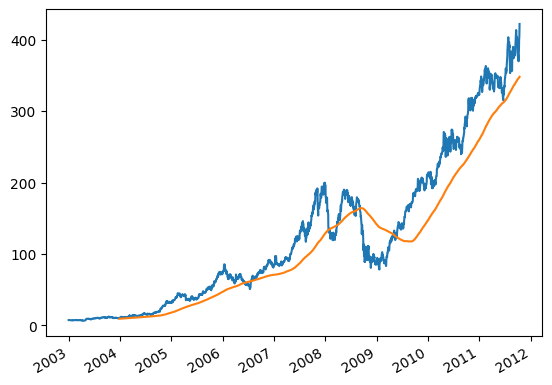

In [93]:
close_px["AAPL"].plot() # 원계열
close_px["AAPL"].rolling(250).mean().plot() # 250일 이동평균